In [1]:
import sys
import importlib

def install_if_missing(package, import_name=None):
    """Install a package only if it's not already installed"""
    import_name = import_name or package
    if importlib.util.find_spec(import_name) is None:
        print(f"Installing {package}...")
        !{sys.executable} -m pip install {package} -q
        print(f"{package} installed ✅")
    else:
        print(f"{package} already available ✅")

install_if_missing("datasets")
install_if_missing("tqdm")
install_if_missing("ipywidgets")

datasets already available ✅
tqdm already available ✅
ipywidgets already available ✅


In [2]:
# Imports
import re
import random
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.optim import Adam

from torchvision import transforms
from datasets import load_dataset
from tqdm import tqdm

print(f"PyTorch version : {torch.__version__}")
print(f"Device : {'cuda' if torch.cuda.is_available() else 'cpu'}")

PyTorch version : 2.3.1
Device : cpu


In [3]:
# Let's create the function that add noise
def add_noise(x0,t):
    # Compute the noise
    noise = torch.randn_like(x0)
    # Get the wanted alpha bar
    ab = alpha_bars[t].view(-1, 1, 1, 1)
    # Compute xt
    x_t = torch.sqrt(ab) * x0 + torch.sqrt(1 - ab) * noise
    return x_t, noise

In [4]:
class TimestepEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

        # At this point we could implement on top of the sinusoide embedding a small MLP to project better

    def sinusoidal_embedding(self, t):
        half  = self.dim // 2
        freqs = torch.exp(
            -torch.arange(half, device=t.device) * (torch.log(torch.tensor(10000.0)) / (half - 1))
        )
        args  = t[:, None].float() * freqs[None]
        emb   = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
        return emb

    def forward(self,t):
        return self.sinusoidal_embedding(t)

In [5]:
class ResBlock(nn.Module):
    def __init__(self, in_channels:int,out_channels:int,emb_dim:int):
        """
        in_channels : number of input channels
        out_channels : number of output channels
        emb_dim : dimension of the timestep embedding
        """

        super().__init__()

        # First block
        self.block1 = nn.Sequential(
            nn.GroupNorm(8, in_channels), #split channels into group of 8
            nn.SiLU(),
            nn.Conv2d(in_channels,out_channels, kernel_size=3,padding=1)
        )

        # Embedding projection
        # We need to project the embedding in order to be in the same space while adding
        self.time_proj = nn.Sequential(
            nn.SiLU(),
            nn.Linear(emb_dim, out_channels)
        )

        # Second block
        self.block2 = nn.Sequential(
            nn.GroupNorm(8, out_channels),
            nn.SiLU(),
            nn.Conv2d(out_channels,out_channels, kernel_size=3,padding=1)
        )

        # Skip connection
        if in_channels != out_channels:
            self.skip = nn.Conv2d(in_channels, out_channels, kernel_size=1) #too match if different
        else:
            self.skip = nn.Identity()

    def forward(self,x,t_emb):
        """
        x     : (B, in_channels, H, W)
        t_emb : (B, emb_dim)
        """

        # First block
        # (B, out_channels, H, W)
        h = self.block1(x)

        # Add time step embedding
        # (B, emb_dim)
        t = self.time_proj(t_emb)
        # (B, out_channels)

        # Add by broadcasting
        h = h + t[:, :, None, None]

        # Second block
        # (B, out_channels, H, W)
        h = self.block2(h)

        # Skip connection
        return h + self.skip(x)

In [6]:
class SelfAttention(nn.Module):
    def __init__(self, channels:int,n_heads:int=4):
        """
        channels : number of input/output channels
        n_heads  : number of attention heads
        """
        super().__init__()
        assert channels % n_heads == 0

        self.channels = channels
        self.n_heads = n_heads
        self.head_dim = channels // n_heads

        # Normalization
        self.norm = nn.GroupNorm(8, channels)

        # Q,K,V Linear
        self.qkv = nn.Linear(channels, channels * 3)
        self.output = nn.Linear(channels,channels)

    def forward(self,x):
        """
        x : (B, C, H, W)
        """

        B,C,H,W = x.shape

        # Norm
        h = self.norm(x)

        # Flatten
        h = h.view(B, C, H * W).transpose(1, 2) # (B, H*W, C)

        # Compute Q, K, V
        qkv = self.qkv(h) # (B, H*W, 3*C)
        q,k,v = qkv.chunk(3, dim=-1) # 3*(B, H*W, C)

        # At this point, the differents head are inside q,k,v s we need to split thoses matrix depending on n_heads
        def split_heads(t):
                    return t.view(B, H * W, self.n_heads, self.head_dim).transpose(1, 2) # (B, n_heads, H*W, head_dim)

        q, k, v = split_heads(q), split_heads(k), split_heads(v)

        # Dot-product attention
        scale  = self.head_dim ** -0.5
        scores = torch.matmul(q, k.transpose(-2, -1)) * scale  # (B, n_heads, H*W, H*W)
        attn   = torch.softmax(scores, dim=-1) # (B, n_heads, H*W, H*W)

        # Weighted sum of values
        out = torch.matmul(attn, v) # (B, n_heads, H*W, head_dim)

        # Merge heads
        out = out.transpose(1, 2).contiguous()  # (B, H*W, n_heads, head_dim)
        out = out.view(B, H * W, C) # (B, H*W, C)

        # Output projection
        out = self.output(out) # (B, H*W, C)

        # Reshape
        out = out.transpose(1, 2).view(B, C, H, W) # (B, C, H, W)

        # Return with residual
        return out + x    
        

In [7]:
class UNet(nn.Module):
    def __init__(
        self, 
        in_channels:int=3,
        base_channels:int=32,
        channel_mults = (1,2,4),
        n_heads = 4,
        emb_dim =128
    ):
        super().__init__()

        self.emb_dim = emb_dim
        channels = [base_channels * i for i in channel_mults]

        # Timestep embedding
        self.time_emb = TimestepEmbedding(emb_dim)

        # init conv
        self.init_conv = nn.Conv2d(in_channels, base_channels, kernel_size=3, padding=1)


        ###########
        # Encoder #
        ###########

        # To increase the number of channels and learn multiple features
        self.encoder_blocks = nn.ModuleList()
        # To reduce the size of the input and see the features more precisely/largelly
        self.downsamplers = nn.ModuleList()

        in_ch = base_channels
        for out_ch in channels:
            self.encoder_blocks.append(nn.ModuleList([
                ResBlock(in_ch,  out_ch, emb_dim), # Changes the channel dimension
                ResBlock(out_ch, out_ch, emb_dim), # Work in the same space -> extracts more complex patterns
            ]))
            self.downsamplers.append(
                nn.Conv2d(out_ch, out_ch, kernel_size=4, stride=2, padding=1)
            )
            in_ch = out_ch

        ##############
        # Bottleneck #
        ##############
        mid_ch = channels[-1]
        self.bottleneck = nn.ModuleList([
            ResBlock(mid_ch, mid_ch, emb_dim),
            SelfAttention(mid_ch, n_heads),
            ResBlock(mid_ch, mid_ch, emb_dim),
        ])

        ###########
        # Decoder #
        ###########
        # Reduce the number of channels and features
        self.decoder_blocks = nn.ModuleList()
        # Increase the size of the value inside the bottlenck
        self.upsamplers      = nn.ModuleList()

        for out_ch in reversed(channels):
            self.upsamplers.append(
                nn.ConvTranspose2d(in_ch, in_ch, kernel_size=4, stride=2, padding=1)
            )
            self.decoder_blocks.append(nn.ModuleList([
                ResBlock(in_ch + out_ch, out_ch, emb_dim),   # +out_ch for skip connection
                ResBlock(out_ch, out_ch, emb_dim),
            ]))
            in_ch = out_ch

        # Final conv that predict the noise
        self.final = nn.Sequential(
            nn.GroupNorm(8, base_channels),
            nn.SiLU(),
            nn.Conv2d(base_channels, in_channels, kernel_size=3, padding=1)
        )
        
    def forward(self, x, t):
        """
        x : (B, 3, 32, 32) noisy image
        t : (B,)            timestep
        returns predicted noise ε (B, 3, 32, 32)
        """

        # Timestep embedding
        t_emb = self.time_emb(t) # (B, emb_dim)

        x = self.init_conv(x) 

        ### Encoder ###
        skips = []
        for (res1, res2), down in zip(self.encoder_blocks, self.downsamplers):
            x = res1(x, t_emb) # First ResBlock
            x = res2(x, t_emb) # Second ResBlock
            skips.append(x)
            x = down(x) # DownSample

        ### Bottleneck ###
        res1, attn, res2 = self.bottleneck
        x = res1(x, t_emb)
        x = attn(x)
        x = res2(x, t_emb)

        ### Decoder ###
        for (res1, res2), up, skip in zip(self.decoder_blocks, self.upsamplers, reversed(skips)):
            x = up(x) # UpSample
            x = torch.cat([x, skip], dim=1) # Add the residual
            x = res1(x, t_emb) # First ResBlock
            x = res2(x, t_emb) # Second ResBlock

        # Final conv
        return self.final(x)



In [8]:
# Parameters
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
T = 1000
beta_start = 1e-4
beta_end = 0.02
betas = torch.linspace(beta_start, beta_end, T).to(device)
alphas = (1 - betas).to(device)
alpha_bars = torch.cumprod(alphas, dim=0).to(device)

In [9]:
# Load the dataset
dataset = load_dataset("jiovine/pixel-art-nouns")['train']

print(f"Number of samples: {len(dataset)}")
print(f"Features: {dataset.features}")

Number of samples: 49859
Features: {'image': Image(mode=None, decode=True), 'text': Value('string')}


In [10]:
# Load the trained model
model = UNet().to(device)

checkpoint = torch.load("pixeldiffusion_epoch_100.pt", map_location=device)
model.load_state_dict(checkpoint['model_state'])
model.eval()

print(f"Model loaded — trained for {checkpoint['epoch']} epochs ✅")
print(f"Last loss : {checkpoint['loss']:.6f}")

Model loaded — trained for 99 epochs ✅
Last loss : 0.006155


# Quality of training

To see the quality of the training, before sampling new data, we can add noise at a certain level to an original image and ask the model to predict the noise, then denoise the initial image with this formula :

$$x_0 = \frac{1}{\sqrt{\bar{\alpha}_t}}\left(x_t - \sqrt{1 - \bar{\alpha}_t} \cdot \varepsilon_{\theta}(x_t, t)\right)$$

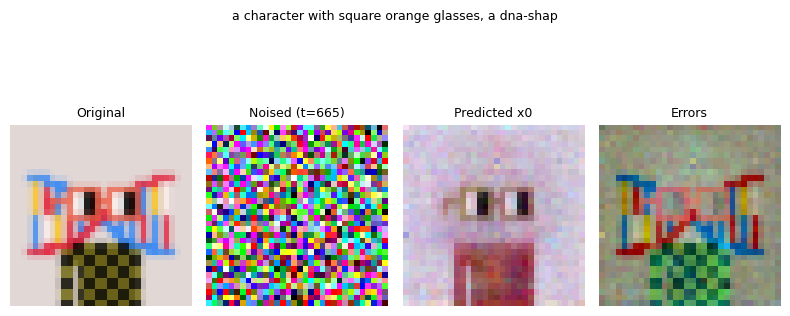

In [13]:
# Get a random image
indice = random.randint(0, len(dataset) - 1)

# Get the image
img = dataset[indice]['image']
label = dataset[indice]['text']

# Take a random t between 0 and T
t = random.randint(0, T - 1)

# Preprocess the image and transform it into a tensor
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

x0 = transform(img).unsqueeze(0).to(device)

# Add the noise
t_tensor = torch.tensor([t]).to(device)
x_t, _ = add_noise(x0, t_tensor)

# Make a prediction
model.eval()
with torch.no_grad():
    eps_pred = model(x_t, t_tensor)

# Remove the prediction from x_t
x0_predicted = (x_t - torch.sqrt(1 - alpha_bars[t]) * eps_pred) / torch.sqrt(alpha_bars[t])

# Display
fig, axes = plt.subplots(1, 4, figsize=(8, 4))

def to_display(tensor):
    img = (tensor.squeeze(0).cpu().permute(1, 2, 0).numpy() + 1) / 2
    return np.clip(img, 0, 1)

axes[0].imshow(to_display(x0),interpolation='nearest')
axes[0].set_title("Original",fontsize=9)

axes[1].imshow(to_display(x_t),interpolation='nearest')
axes[1].set_title(f"Noised (t={t})",fontsize=9)

axes[2].imshow(to_display(x0_predicted),interpolation='nearest')
axes[2].set_title("Predicted x0",fontsize=9)

axes[3].imshow(to_display(x0-x0_predicted),interpolation='nearest')
axes[3].set_title("Errors",fontsize=9)

for ax in axes:
    ax.axis('off')

plt.suptitle(label[:50], fontsize=9)
plt.tight_layout()
plt.show()

# Sampling

In this part, we aim to generate images from pure noise. If $T$ is large enough, the successive forward transformations are sufficiently incremental to assume that the reverse transformation is Gaussian. We train the model to predict at each timestep $t$ the current noise $\varepsilon_{\theta}(x_t, t)$.

We can show that :

$$p(x_{t-1}|x_t) = \mathcal{N}\left(x_{t-1}; \frac{1}{\sqrt{\alpha_t}} \left(x_t - \frac{1 - \alpha_t}{\sqrt{1-\bar{\alpha}_t}} \varepsilon_{\theta}(x_t,t)\right), \beta_t I\right)$$

And so we can obtain $x_{t-1}$ by sampling :

$$x_{t-1} = \frac{1}{\sqrt{\alpha_t}}\left(x_t - \frac{1 - \alpha_t}{\sqrt{1-\bar{\alpha}_t}} \varepsilon_{\theta}(x_t,t)\right) + \sqrt{\beta_t} \cdot z$$

Where $z \sim \mathcal{N}(0, I)$ is a noise sample drawn across all image dimensions. It introduces stochasticity into the reverse process, ensuring diverse and non-deterministic generations.

Sampling: 100%|█████████████████████████████| 1000/1000 [00:41<00:00, 24.30it/s]


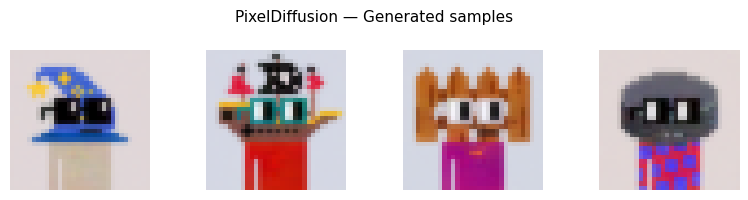

In [12]:
# Sampling
@torch.no_grad()
def sample(model, n_samples=4, device=device):

    # Eval mode
    model.eval()

    # Generate pure noise
    x = torch.randn(n_samples, 3, 32, 32, device=device)

    # Reverse the diffusion loop
    for t in tqdm(reversed(range(T)), desc="Sampling", total=T):

        # Current timestep for all samples
        t_tensor = torch.full((n_samples,), t, device=device, dtype=torch.long)

        # Predict noise
        eps_pred = model(x, t_tensor) # (B, 3, 32, 32)

        # Compute the different value of alpha, alpha_bar and beta
        alpha_t = alphas[t]
        alpha_bar_t = alpha_bars[t]
        beta_t = betas[t]

        # Compute x_{t-1}
        coeff = (1 - alpha_t) / torch.sqrt(1 - alpha_bar_t)
        x_prev = (1 / torch.sqrt(alpha_t)) * (x - coeff * eps_pred)

        # Add noise only if t > 0 -> To add diversity
        if t > 0:
            z   = torch.randn_like(x)
            x_prev = x_prev + torch.sqrt(beta_t) * z

        x = x_prev

    return x  # (n_samples, 3, 32, 32)


# Diplay samples
def display_samples(samples, title="Generated Pixel Art"):
    n = samples.shape[0]
    fig, axes = plt.subplots(1, n, figsize=(n * 2, 2))

    if n == 1:
        axes = [axes]

    for ax, img in zip(axes, samples):
        # Denormalize [-1, 1] → [0, 1]
        img_display = (img.cpu().permute(1, 2, 0).numpy() + 1) / 2
        img_display = np.clip(img_display, 0, 1)

        ax.imshow(img_display, interpolation='nearest')
        ax.axis('off')

    plt.suptitle(title, fontsize=11)
    plt.tight_layout()
    plt.show()
    
# Samples 
samples = sample(model, n_samples=4)

# Display
display_samples(samples, title="PixelDiffusion — Generated samples")